# How concepts spread: early reach vs keeping fields (RQ2 trajectories — demo)

This notebook is a runnable demo of the **RQ2 trajectories** experiment. The question: when a research concept (from OpenAlex) spreads beyond its home field, does it end up with **broader retained reach** mainly because it **contacts more fields early** or because it **keeps more of the fields it enters**?

The artifact's `method.py` is a **driver**. It runs the pipeline stages S0 … S10 plus T7/T0/audit, each as its own script. Most stages read large caches from other artifacts of the same run (EXP5/6/7/8 panels, ego networks, 5.56M field-state cells), so they cannot run in Colab. This notebook therefore:

1. shows the driver's stage plan (`steps()` from `method.py`, verbatim);
2. re-runs the core **S4 decomposition** stage (`s4_decomp.py` + `lib/decomp.py`, copied verbatim) on a **100-concept DEV subset**. That stage is the exact log-additive split of the top-vs-bottom `O2r_resid` tercile gap in retained off-home breadth:
   $\log B_n = \log E_2\ (\text{early contact}) + \log M\ (\text{frontier advance}) + \log \rho\ (\text{retention})$,
   followed by the pre-registered verdicts PR1/PR1b/PR2 and the T9 placebo;
3. re-runs the **OPEN-on-the-axis** test from `s5_typology.py`: partial Spearman of early ego-network openness with the continuum axes PC1/PC2, given the B5 baseline plus label coverage;
4. plots the results next to the full-run headline numbers (DEV, 4,771 concepts).

The per-concept inputs (`E2`, `EH`, `Bn`, `O2r_resid`, B5 covariates, OPEN builds, PC1/PC2) come from the artifact's own output dataset `rq2_concepts`. With only 100 concepts the numbers are **noisy illustrations**. The full-run values are printed alongside them for comparison.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# The analysis code only needs numpy / pandas / scipy (+ matplotlib for the plots) — all pre-installed on Colab.
# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
The first block is the original import block of `method.py`. The second block holds the imports that `lib/decomp.py`, `lib/rq1stats.py` and `s4_decomp.py` use, plus matplotlib for the plots.

In [2]:
# --- method.py (original import block)
from __future__ import annotations

import argparse
import subprocess
import sys
import time
from pathlib import Path

# --- lib/decomp.py, lib/rq1stats.py, s4_decomp.py, s5_typology.py
import math
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata

# --- notebook additions (display / plots)
import json
import matplotlib.pyplot as plt

## Data loading
`mini_demo_data.json` holds 100 DEV concepts, 25 each from CS, Eng, BGM and Med, sampled with seed 20260929 from the 12,499-concept `rq2_concepts` dataset. Every concept has a finite `O2r_resid` outcome. The file also stores the full run's headline numbers under `metadata.headline_full_run`. The notebook loads it from GitHub and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-4/experiment-12/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["method_name"])
print("concepts in demo subset:", len(data["datasets"][0]["examples"]))

RQ2 contact-vs-retention decomposition + trajectory typology/continuum (cache-only re-run)
concepts in demo subset: 100


## Configuration
These are all the tunable parameters. The values used in the original full run are given in the comments. On the 100-concept demo subset, the original values run in well under a minute, so the demo uses them as is.

In [5]:
SEED = 20260929        # original: 20260929 (lib/common.py)
N_BOOT = 2000          # concept-bootstrap resamples for the decomposition / PR2   (original: 2000)
N_BOOT_OPEN = 2000     # bootstrap resamples for OPEN ~ PC partial Spearman       (original: 2000)
N_PLACEBO = 200        # T9 placebo shuffles of O2r_resid within group             (original: 200)
WORKERS = 2            # process-pool workers for the variant jobs                 (original: 24 / 13)

## 1. The driver: `method.py`'s stage plan
This is `steps()` copied verbatim from `method.py`. Each stage is a separate script that reads upstream caches. The original `main()` launches each one with `subprocess.run`. Here we only **print** the plan, because those caches are not in the demo data. The cells below re-run the parts of **S4** and **S5** that work on per-concept data.

In [6]:
ROOT = Path(".").resolve()   # method.py: Path(__file__).resolve().parent
PY = sys.executable


def steps(workers: int) -> list[tuple[str, list[str]]]:
    return [("S0", ["s0_skeleton.py"]),
            ("S2", ["s2_open.py", "--stage", "all", "--workers", str(workers)]),
            ("S3", ["s3_states.py"]),
            ("S4", ["s4_decomp.py", "--scope", "dev"]),
            ("S5", ["s5_typology.py", "--scope", "dev", "--workers", str(workers)]),
            ("S6", ["s6_sequence.py", "--scope", "dev"]),
            ("S7", ["s7_seal.py", "--freeze"] if not (ROOT / "logs/unsealed.json").exists() else []),
            ("S7run", ["s7_seal.py", "--run"]),
            ("S8", ["s8_cases.py"]),
            ("S9", ["s9_atlas.py"]),
            ("S10", ["s10_outputs.py"]),
            ("T7", ["rederive.py"]),
            ("T0", ["tests/test_units.py"]),
            ("AUDIT", ["audit_headlines.py"])]


# notebook: print the plan instead of `subprocess.run([PY, str(ROOT / cmd[0])] + cmd[1:], cwd=ROOT)`
IN_NOTEBOOK = {"S4": "decomposition + PR verdicts + T9 placebo (below)", "S5": "OPEN on the PC1/PC2 axes (below)"}
for name, cmd in steps(WORKERS):
    print(f"[{name:5s}] {' '.join(cmd):55s} {'-> re-run here: ' + IN_NOTEBOOK[name] if name in IN_NOTEBOOK else ''}")

[S0   ] s0_skeleton.py                                          
[S2   ] s2_open.py --stage all --workers 2                      
[S3   ] s3_states.py                                            
[S4   ] s4_decomp.py --scope dev                                -> re-run here: decomposition + PR verdicts + T9 placebo (below)
[S5   ] s5_typology.py --scope dev --workers 2                  -> re-run here: OPEN on the PC1/PC2 axes (below)
[S6   ] s6_sequence.py --scope dev                              
[S7   ] s7_seal.py --freeze                                     
[S7run] s7_seal.py --run                                        
[S8   ] s8_cases.py                                             
[S9   ] s9_atlas.py                                             
[S10  ] s10_outputs.py                                          
[T7   ] rederive.py                                             
[T0   ] tests/test_units.py                                     
[AUDIT] audit_headlines.py                 

## 2. Shared constants (`lib/common.py`) and statistics helpers (`lib/rq1stats.py`)
- **B5** is the five-covariate early baseline: log volume, growth, off-home share, entropy and reach.
- `psp_boot` is a partial Spearman correlation. Both variables are rank-residualised on the covariates, and the residualisation is refitted in every bootstrap resample.
- `holm` is the Holm multiplicity correction and `dersimonian_laird` is random-effects pooling.

All of these are copied verbatim.

In [7]:
# lib/common.py (constants used here)
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
HELD_GROUPS = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]
UNITS = HELD_GROUPS + ["COH_DEVHOME", "COH_OTHER"]
DISCLOSURE = ("held-out outcomes were previously unsealed by EXP5/EXP7/EXP8; this seal fixes only this artifact's "
              "analysis choices (fixed on DEV before held-out states/outcomes were read by this artifact)")


# lib/rq1stats.py (verbatim)
def _resid(Z: np.ndarray, Y: np.ndarray) -> np.ndarray:
    beta, *_ = np.linalg.lstsq(Z, Y, rcond=None)
    return Y - Z @ beta


def psp_point(x: np.ndarray, y: np.ndarray, B: np.ndarray, cat: np.ndarray | None) -> float:
    '''Pearson(resid(rank x ~ rank B + cat dummies), resid(rank y ~ same)). Rows must be complete.'''
    Zc = [np.ones((len(x), 1))]
    if B is not None and B.shape[1]:
        Zc.append(rankdata(B, axis=0))
    if cat is not None and cat.shape[1]:
        Zc.append(cat)
    Z = np.hstack(Zc)
    R = _resid(Z, np.c_[rankdata(x), rankdata(y)])
    sx, sy = R[:, 0].std(), R[:, 1].std()
    if sx <= 1e-12 or sy <= 1e-12:
        return float("nan")
    return float(np.corrcoef(R[:, 0], R[:, 1])[0, 1])


def psp_boot(x, y, B, cat, n_boot: int, seed: int) -> dict:
    '''Point + concept bootstrap (resample rows; ranks and residualisation recomputed in each resample).'''
    ok = np.isfinite(x) & np.isfinite(y)
    if B is not None:
        ok &= np.all(np.isfinite(B), axis=1)
    x, y = x[ok], y[ok]
    Bs = B[ok] if B is not None else None
    cs = cat[ok] if cat is not None else None
    n = len(x)
    if n < 20 or np.unique(x).size < 3:
        return {"n": int(n), "rho": float("nan"), "ci": [float("nan")] * 2, "se": float("nan"), "p": float("nan"),
                "boot": np.array([])}
    est = psp_point(x, y, Bs, cs)
    rng = np.random.default_rng(seed)
    bs = np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        bs[b] = psp_point(x[i], y[i], Bs[i] if Bs is not None else None, cs[i] if cs is not None else None)
    bs = bs[np.isfinite(bs)]
    lo, hi = np.percentile(bs, [2.5, 97.5]) if len(bs) else (np.nan, np.nan)
    z = np.arctanh(np.clip(bs, -0.999999, 0.999999))
    se_z = float(np.std(z, ddof=1)) if len(z) > 2 else float("nan")
    ze = math.atanh(max(min(est, 0.999999), -0.999999)) if np.isfinite(est) else float("nan")
    p = float(2 * stats.norm.sf(abs(ze / se_z))) if se_z and np.isfinite(se_z) and se_z > 0 else float("nan")
    return {"n": int(n), "rho": est, "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "z": ze, "se_z": se_z, "p": p, "boot": bs}


def dersimonian_laird(b, se) -> dict:
    '''EXP6 lib/stats_core.dersimonian_laird (verbatim logic).'''
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0, "b": float("nan"), "se": float("nan"), "ci": [float("nan")] * 2, "p": float("nan"),
                "tau2": float("nan"), "I2": float("nan"), "Q": float("nan")}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    Cc = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / Cc) if k > 1 and Cc > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}


def holm(p: list[float]) -> list[float]:
    p = np.asarray(p, float)
    out = np.full(len(p), np.nan)
    ok = np.isfinite(p)
    idx = np.nonzero(ok)[0]
    m = len(idx)
    order = idx[np.argsort(p[idx])]
    run = 0.0
    for r, i in enumerate(order):
        run = max(run, min(1.0, (m - r) * p[i]))
        out[i] = run
    return out.tolist()

## 3. The exact decomposition (`lib/decomp.py`, verbatim)
Each concept has these counts, with the horizon H = 8 years after its onset year t0:
- `E2`: off-home fields **entered** by age 2 (early contact)
- `EH`: off-home fields entered by age 8
- `Bn`: off-home fields still **retained** at age 8

At the **group level** the identity is exact even when some counts are zero:
mean Bn = mean E2 × M × ρ, where M = ΣEH/ΣE2 is the frontier advance and ρ = ΣBn/ΣEH is retention.

For each factor k, `D_k = log f_k(top tercile) − log f_k(bottom tercile)`, and its share is `D_k / Σ D_k`. Because the identity is log-additive, `D_k` is exactly that factor's Shapley value. The volume-stratified variants average the `D_k` over early-volume quintiles. Strata where a factor is undefined are merged with the adjacent stratum.

In [8]:
FACTORS = ["E2", "M", "rho"]
MIN_PER_TERCILE_CI = 30          # fallback 8: fewer concepts per tercile -> no CI, excluded from DL


def terciles(y: np.ndarray, by: np.ndarray | None) -> tuple[np.ndarray, np.ndarray]:
    '''top / bottom tercile masks of y, computed within each level of `by` (or the whole sample).'''
    top = np.zeros(len(y), bool)
    bot = np.zeros(len(y), bool)
    levels = [None] if by is None else np.unique(by)
    for g in levels:
        m = np.ones(len(y), bool) if g is None else by == g
        if m.sum() < 3:
            continue
        lo, hi = np.quantile(y[m], [1 / 3, 2 / 3])
        top |= m & (y > hi)
        bot |= m & (y <= lo)
    return top, bot


def quantile_bins(v: np.ndarray, q: int) -> np.ndarray:
    edges = np.quantile(v, np.linspace(0, 1, q + 1)[1:-1])
    return np.searchsorted(edges, v, side="right")


def _factors(E2, EH, Bn) -> tuple[float, float, float]:
    se2, seh, sbn = E2.sum(), EH.sum(), Bn.sum()
    if len(E2) == 0 or se2 <= 0 or seh <= 0 or sbn <= 0:
        return (math.nan,) * 3
    return float(E2.mean()), float(seh / se2), float(sbn / seh)


def _stratum_ok(E2, EH, Bn, t, b) -> bool:
    return t.sum() > 0 and b.sum() > 0 and all(np.isfinite(_factors(E2[m], EH[m], Bn[m])).all() for m in (t, b))


def merge_strata(strata: np.ndarray, E2, EH, Bn, top, bot, family: np.ndarray | None = None) -> tuple[np.ndarray, int]:
    '''merge adjacent (ordered) strata until each has valid factors in both terciles; within `family` levels.'''
    out = strata.copy()
    merges = 0
    fams = [None] if family is None else np.unique(family)
    for f in fams:
        fm = np.ones(len(strata), bool) if f is None else family == f
        levels = sorted(np.unique(strata[fm]))
        buckets, cur = [], []
        for s in levels:
            cur.append(s)
            m = fm & np.isin(strata, cur)
            if _stratum_ok(E2, EH, Bn, top & m, bot & m):
                buckets.append(cur)
                cur = []
        if cur:
            if buckets:
                buckets[-1] = buckets[-1] + cur
            else:
                buckets.append(cur)
        merges += len(levels) - len(buckets)
        for bk in buckets:
            out[fm & np.isin(strata, bk)] = bk[0]
    return out, merges


def gap(E2, EH, Bn, top, bot, strata: np.ndarray | None = None, family: np.ndarray | None = None) -> dict:
    '''D_k (n-weighted over strata), shares, and the unstratified factor levels.'''
    if strata is None:
        strata = np.zeros(len(E2), int)
    st, merges = merge_strata(strata, E2, EH, Bn, top, bot, family)
    keys = st * 1000 + (0 if family is None else family)
    Dw = np.zeros(3)
    W = 0.0
    n_str = 0
    for s in np.unique(keys):
        m = keys == s
        t, b = top & m, bot & m
        ft, fb = _factors(E2[t], EH[t], Bn[t]), _factors(E2[b], EH[b], Bn[b])
        if not (np.isfinite(ft).all() and np.isfinite(fb).all()):
            continue
        w = float(t.sum() + b.sum())
        Dw += w * (np.log(ft) - np.log(fb))
        W += w
        n_str += 1
    D = Dw / W if W > 0 else np.full(3, np.nan)
    tot = D.sum()
    sh = D / tot if np.isfinite(tot) and abs(tot) > 1e-12 else np.full(3, np.nan)
    ft, fb = _factors(E2[top], EH[top], Bn[top]), _factors(E2[bot], EH[bot], Bn[bot])
    return {"D_E2": D[0], "D_M": D[1], "D_rho": D[2], "D_total": tot, "s_E2": sh[0], "s_M": sh[1], "s_rho": sh[2],
            "s_explore": sh[0] + sh[1], "s_contact": sh[0], "s_ret": sh[2],
            "diff_explore_ret": (sh[0] + sh[1]) - sh[2], "diff_contact_ret": sh[0] - sh[2],
            "top_Ebar": ft[0], "top_M": ft[1], "top_rho": ft[2], "bot_Ebar": fb[0], "bot_M": fb[1], "bot_rho": fb[2],
            "top_Bbar": float(Bn[top].mean()) if top.any() else math.nan,
            "bot_Bbar": float(Bn[bot].mean()) if bot.any() else math.nan,
            "n_top": int(top.sum()), "n_bot": int(bot.sum()), "n_strata": n_str, "merges": merges}


def das_gupta(E2, EH, Bn, top, bot) -> dict:
    '''additive 3-factor Das Gupta decomposition of Bbar(top) - Bbar(bottom) (pooled).'''
    a1, b1, c1 = _factors(E2[top], EH[top], Bn[top])
    a2, b2, c2 = _factors(E2[bot], EH[bot], Bn[bot])

    def eff(x1, x2, y1, y2, z1, z2):
        return (x1 - x2) * ((y1 * z1 + y2 * z2) / 3 + (y1 * z2 + y2 * z1) / 6)
    eA = eff(a1, a2, b1, b2, c1, c2)
    eB = eff(b1, b2, a1, a2, c1, c2)
    eC = eff(c1, c2, a1, a2, b1, b2)
    g = a1 * b1 * c1 - a2 * b2 * c2
    return {"effect_E2": eA, "effect_M": eB, "effect_rho": eC, "gap_Bbar": g, "sum_effects": eA + eB + eC,
            "share_E2": eA / g, "share_M": eB / g, "share_rho": eC / g}


def concept_cov(E2, EH, Bn) -> dict:
    '''exact covariance decomposition var(log Bn) = sum_k cov(log Bn, log f_k) among Bn >= 1.'''
    m = (Bn >= 1) & (E2 >= 1)
    lb = np.log(Bn[m])
    le, lm, lr = np.log(E2[m]), np.log(EH[m] / E2[m]), np.log(Bn[m] / EH[m])
    v = lb.var()
    cs = [float(np.cov(lb, x, bias=True)[0, 1]) for x in (le, lm, lr)]
    return {"n": int(m.sum()), "var_logBn": float(v), "cov_E2": cs[0], "cov_M": cs[1], "cov_rho": cs[2],
            "share_E2": cs[0] / v, "share_M": cs[1] / v, "share_rho": cs[2] / v,
            "identity_max_abs_err": float(np.max(np.abs(lb - (le + lm + lr)))) if m.any() else 0.0}


def run_variant(d: dict, spec: dict, rng: np.random.Generator | None, n_boot: int) -> dict:
    '''d: arrays E2, EH, Bn, y (tercile outcome), logvol_early, med, tby (tercile-within levels or None),
    rs (resampling strata, e.g. unit). spec: strata in {none, vol, vol_med}.'''
    def once(idx: np.ndarray | None) -> dict:
        g = (lambda a: a) if idx is None else (lambda a: None if a is None else a[idx])  # noqa: E731
        E2, EH, Bn, y = g(d["E2"]), g(d["EH"]), g(d["Bn"]), g(d["y"])
        top, bot = terciles(y, g(d.get("tby")))
        strata = family = None
        if spec["strata"] in ("vol", "vol_med"):
            lv = g(d["logvol_early"])
            tb = g(d.get("tby"))
            if tb is None:
                strata = quantile_bins(lv, 5)
            else:  # quintiles within each tercile-level (unit) so strata never mix units
                strata = np.zeros(len(lv), int)
                for u in np.unique(tb):
                    m = tb == u
                    strata[m] = quantile_bins(lv[m], 5)
                family = np.unique(tb, return_inverse=True)[1]
        if spec["strata"] == "vol_med":
            med = g(d["med"]).astype(int)
            family = med if family is None else family * 2 + med
        return gap(E2, EH, Bn, top, bot, strata, family)
    point = once(None)
    out = {"point": point, "n": int(len(d["E2"]))}
    if rng is None or n_boot <= 0:
        return out
    n = len(d["E2"])
    rs = d.get("rs")
    groups = [np.arange(n)] if rs is None else [np.nonzero(rs == u)[0] for u in np.unique(rs)]
    keys = ["D_E2", "D_M", "D_rho", "D_total", "s_E2", "s_M", "s_rho", "s_explore", "s_contact", "s_ret",
            "diff_explore_ret", "diff_contact_ret"]
    B = {k: np.empty(n_boot) for k in keys}
    for b in range(n_boot):
        idx = np.concatenate([gi[rng.integers(0, len(gi), len(gi))] for gi in groups])
        r = once(idx)
        for k in keys:
            B[k][b] = r[k]
    out["ci"] = {k: [float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5))] for k, v in B.items()}
    out["se"] = {k: float(np.nanstd(v, ddof=1)) for k, v in B.items()}
    out["p_two_sided"] = {k: float(min(1.0, 2 * min(np.nanmean(v <= 0), np.nanmean(v >= 0)))) for k, v in B.items()}
    out["boot_nan_share"] = float(np.mean(~np.isfinite(B["s_ret"])))
    out["_boot"] = B
    return out


def verdict(ci: list[float]) -> str:
    lo, hi = ci
    if not (np.isfinite(lo) and np.isfinite(hi)):
        return "NOT EVALUABLE"
    if lo > 0:
        return "SUPPORTED"
    if hi < 0:
        return "REVERSED"
    return "NOT SUPPORTED"


class DC:  # notebook: stands in for `import decomp as DC` so the s4_decomp.py code below is unchanged
    terciles, quantile_bins, gap, das_gupta, concept_cov = (staticmethod(terciles), staticmethod(quantile_bins),
                                                          staticmethod(gap), staticmethod(das_gupta),
                                                          staticmethod(concept_cov))
    run_variant, verdict, MIN_PER_TERCILE_CI = staticmethod(run_variant), staticmethod(verdict), MIN_PER_TERCILE_CI

## 4. Building the concept table (replaces `s4_decomp.load_table`)
The original script joins `data/joined.parquet`, `data/decomp_inputs.parquet` and the EXP8 outcomes. Here the same columns are rebuilt from the demo JSON. `logvol_early = log(early_volume)` is unchanged.

The robustness counts `*_mn3`, `*_mn5` and `*_onset`, and the outcomes `O2r_m50` and `O1b`, are not in the demo data. The variants that need them are skipped (see the next cell).

In [9]:
def load_table(scope: str) -> pd.DataFrame:
    rows = []
    for e in data["datasets"][0]["examples"]:
        inp, out = json.loads(e["input"]), json.loads(e["output"])
        rows.append({"ci": e["metadata_ci"], "name": inp["name"], "group": e["metadata_group"], "split": e["metadata_split"],
                     "unit": e["metadata_unit"], "rgroup": e["metadata_rgroup"], "med_home": e["metadata_med_home"],
                     "in_exp6": e["metadata_in_exp6"], "intersection_born": e["metadata_intersection_born"],
                     **inp["B5"], "OPEN_all": inp["OPEN_all"], "OPEN_home": inp["OPEN_home"], "OPEN_size": inp["OPEN_size"],
                     "RETENTION_RATIO_early": inp["RETENTION_RATIO_early"],
                     "RETENTION_RATIO_missing": e["metadata_RETENTION_RATIO_missing"],
                     "label_coverage_early": e["metadata_label_coverage_early"], "early_volume": e["metadata_early_volume"],
                     "O2r_resid": out["O2r_resid"], "E2": out["E2"], "EH": out["EH"], "Bn": out["Bn"],
                     "dtw_class": out["dtw_class"], "PC1": out["PC1"], "PC2": out["PC2"]})
    T = pd.DataFrame(rows)
    T = T[T.split == "DEV"] if scope == "dev" else T
    T["O2r_resid"] = T.O2r_resid.astype(float)
    T["logvol_early"] = np.log(T.early_volume)
    return T.reset_index(drop=True)


T = load_table("dev")
print(T.shape, T.group.value_counts().to_dict())
T[["name", "group", "E2", "EH", "Bn", "O2r_resid", "OPEN_all", "PC1", "PC2"]].head(8)

(100, 29) {'CS': 25, 'Eng': 25, 'BGM': 25, 'Med': 25}


,name,group,E2,EH,Bn,O2r_resid,OPEN_all,PC1,PC2
0,Information hiding,CS,2,4,2,-1.638858,-0.066688,3.771323,3.175664
1,Shortest path problem,CS,4,6,3,0.548048,-0.090523,6.750677,0.841197
2,Vertex cover,CS,4,4,4,0.541259,-0.157247,2.795039,2.232101
3,Semi-supervised learning,CS,3,4,1,1.075651,0.137009,2.420625,0.849995
4,Crowdsourcing,CS,7,17,15,5.308775,3.640158,13.781626,3.713609
5,Graph coloring,CS,4,5,4,1.552399,-0.314238,5.032891,-2.320390
6,Multi-core processor,CS,2,8,6,-0.379364,1.328767,3.531272,3.642377
7,Apriori algorithm,CS,2,6,3,0.055882,0.005552,3.629138,3.606301


## 5. S4: pre-registration, variants and the analysis functions (`s4_decomp.py`, verbatim)
**PR1** (the main claim): in the volume-stratified, Medicine-excluded variant, `s_explore − s_ret > 0`, with a bootstrap CI above 0. Here `s_explore = s_E2 + s_M` and `s_ret = s_rho`.

**PR2**: concepts that stay local keep a larger share of the fields they touch early. It is tested with a bottom-minus-top difference in `RETENTION_RATIO_early` together with a negative partial Spearman given B5.

The notebook only adds the `AVAILABLE` filter, which drops variants whose columns are not in the demo table. It also keeps `analyze` from pre-filtering on `O2r_resid` (all demo concepts have it).

In [10]:
PREREG = {
    "PR1": ("EXPLORATION > RETENTION: in variant (iv) [volume-stratified (early-volume quintiles), concepts with a "
            "Medicine (field 27) home excluded], s_explore - s_ret > 0 with the 95% concept-bootstrap CI > 0, where "
            "s_explore = s_E2 + s_M and s_ret = s_rho are the shares of the top-vs-bottom O2r_resid tercile gap in "
            "log mean breadth (Bn = retained off-home fields at t0+8). Equivalently s_ret < 0.5; both are printed "
            "(shares sum to 1)."),
    "PR1b": "(secondary, Holm family R2-A with PR1 and PR2): s_contact - s_ret > 0 with CI > 0 (s_contact = s_E2).",
    "PR2": ("LOCALISED KEEP MORE EARLY: mean RETENTION_RATIO_early(bottom O2r_resid tercile) - mean(top tercile) > 0 "
            "with CI > 0, AND the partial Spearman of RETENTION_RATIO_early with O2r_resid given B5 < 0 (CI < 0). The "
            "latter is flagged 'replication on the same frame as EXP8, not new evidence'."),
    "PR3": "(descriptive, not tested): the sign of D_rho, i.e. whether late retention probability is lower for "
           "integrating (top-tercile) concepts.",
    "verdict_rule": "per clause: SUPPORTED (CI on the predicted side) / NOT SUPPORTED (CI covers 0) / REVERSED "
                    "(CI on the opposite side); evaluated separately on DEV and on held-out.",
    "holm_family_R2A": ["PR1", "PR1b", "PR2"],
}

VARIANTS = {   # name: (strata, subset, y column, decomp suffix)
    "i_pooled": ("none", None, "O2r_resid", ""),
    "ii_vol_PRIMARY": ("vol", None, "O2r_resid", ""),
    "iii_vol_med_adjusted": ("vol_med", None, "O2r_resid", ""),
    "iv_vol_noMed_PR1": ("vol", "nomed", "O2r_resid", ""),
    "v_minn3": ("vol", None, "O2r_resid", "_mn3"),
    "v_minn5": ("vol", None, "O2r_resid", "_mn5"),
    "v_minn3_noMed": ("vol", "nomed", "O2r_resid", "_mn3"),
    "v_minn5_noMed": ("vol", "nomed", "O2r_resid", "_mn5"),
    "vi_O2r_m50": ("vol", None, "O2r_m50", ""),
    "vi_O1b_sustained_only": ("vol", "o1b", "O2r_resid", ""),
    "viii_onset_restricted": ("vol", None, "O2r_resid", "_onset"),
    "viii_onset_restricted_noMed": ("vol", "nomed", "O2r_resid", "_onset"),
    "ix_noEXP6_noMed": ("vol", "noexp6_nomed", "O2r_resid", ""),
}
BOOT_KEYS = ["D_E2", "D_M", "D_rho", "diff_explore_ret", "diff_contact_ret", "s_ret"]

# notebook: keep only the variants whose columns exist in the demo table
AVAILABLE = {k: v for k, v in VARIANTS.items()
             if f"E2{v[3]}" in T.columns and v[2] in T.columns and v[1] != "o1b"}
print("variants run here:", list(AVAILABLE))
print("skipped (inputs not in demo data):", [k for k in VARIANTS if k not in AVAILABLE])


def arrays(T: pd.DataFrame, suffix: str, ycol: str, tby=None, rs=None) -> dict:
    return {"E2": T[f"E2{suffix}"].to_numpy(float), "EH": T[f"EH{suffix}"].to_numpy(float),
            "Bn": T[f"Bn{suffix}"].to_numpy(float), "y": T[ycol].to_numpy(float),
            "logvol_early": T.logvol_early.to_numpy(float), "med": T.med_home.to_numpy(int),
            "tby": None if tby is None else T[tby].to_numpy(), "rs": None if rs is None else T[rs].to_numpy()}


def subset(T: pd.DataFrame, which: str | None) -> pd.DataFrame:
    if which is None:
        return T
    if which == "nomed":
        return T[T.med_home == 0]
    if which == "o1b":   # plan says 'O1c = 1'; O1c is continuous in EXP8, the binary sustained-uptake outcome is O1b
        return T[T.O1b == 1]
    if which == "noexp6_nomed":
        return T[(T.med_home == 0) & (T.in_exp6 == 0)]
    raise ValueError(which)


def _job(args):
    name, T, spec, tby, rs, seed, n_boot = args
    strata, sub, ycol, suf = spec
    S = subset(T, sub)
    S = S[np.isfinite(S[ycol])]
    res = DC.run_variant(arrays(S, suf, ycol, tby, rs), {"strata": strata}, np.random.default_rng(seed), n_boot)
    B = res.pop("_boot", None)
    res["boot_quantiles"] = {k: np.nanpercentile(B[k], [2.5, 5, 25, 50, 75, 95, 97.5]).tolist()
                             for k in BOOT_KEYS} if B is not None else None
    res["spec"] = {"strata": strata, "subset": sub, "y": ycol, "counts_suffix": suf or "min_n=2"}
    tn = min(res["point"]["n_top"], res["point"]["n_bot"])
    res["ci_reported"] = tn >= DC.MIN_PER_TERCILE_CI
    return name, res


def early_ratio(T: pd.DataFrame, seed: int, n_boot: int, tby=None) -> dict:
    '''PR2: RETENTION_RATIO_early bottom - top tercile (concepts with >= 1 off-home contact) + psp given B5.'''
    S = T[np.isfinite(T.O2r_resid) & (T.RETENTION_RATIO_missing == 0)]
    y = S.O2r_resid.to_numpy()
    rr = S.RETENTION_RATIO_early.to_numpy()
    tb = None if tby is None else S[tby].to_numpy()
    rng = np.random.default_rng(seed)

    def diff(idx):
        top, bot = DC.terciles(y[idx], None if tb is None else tb[idx])
        return rr[idx][bot].mean() - rr[idx][top].mean()
    n = len(S)
    pt = diff(np.arange(n))
    bs = np.array([diff(rng.integers(0, n, n)) for _ in range(n_boot)])
    ps = psp_boot(rr, y, S[B5].to_numpy(float), None, n_boot, seed + 7)
    top, bot = DC.terciles(y, tb)
    return {"n": n, "mean_bottom": float(rr[bot].mean()), "mean_top": float(rr[top].mean()),
            "diff_bottom_minus_top": float(pt), "ci": np.percentile(bs, [2.5, 97.5]).tolist(),
            "se": float(bs.std(ddof=1)), "p_two_sided": float(min(1, 2 * min((bs <= 0).mean(), (bs >= 0).mean()))),
            "psp_given_B5": {k: ps[k] for k in ("n", "rho", "ci", "se", "p")},
            "note_psp": "replication on the same frame as EXP8, not new evidence"}


def analyze(T: pd.DataFrame, label: str, seed: int, tby=None, rs=None, n_boot: int = N_BOOT,
            variants=AVAILABLE, workers: int = WORKERS) -> dict:
    jobs = [(name, T, spec, tby, rs, seed + k, n_boot) for k, (name, spec) in enumerate(variants.items())]
    with ProcessPoolExecutor(min(workers, len(jobs))) as ex:
        res = dict(ex.map(_job, jobs))
    out = {"label": label, "n_concepts_with_outcome": int(np.isfinite(T.O2r_resid).sum()), "variants": res}
    S = T[np.isfinite(T.O2r_resid)]
    top, bot = DC.terciles(S.O2r_resid.to_numpy(), None if tby is None else S[tby].to_numpy())
    a = arrays(S, "", "O2r_resid")
    out["das_gupta_pooled"] = DC.das_gupta(a["E2"], a["EH"], a["Bn"], top, bot)
    out["concept_level_cov"] = DC.concept_cov(a["E2"], a["EH"], a["Bn"])
    out["early_ratio_PR2"] = early_ratio(T, seed + 99, n_boot, tby)
    out["early_ratio_PR2_noMed"] = early_ratio(T[T.med_home == 0], seed + 98, n_boot, tby)
    return out

variants run here: ['i_pooled', 'ii_vol_PRIMARY', 'iii_vol_med_adjusted', 'iv_vol_noMed_PR1', 'ix_noEXP6_noMed']
skipped (inputs not in demo data): ['v_minn3', 'v_minn5', 'v_minn3_noMed', 'v_minn5_noMed', 'vi_O2r_m50', 'vi_O1b_sustained_only', 'viii_onset_restricted', 'viii_onset_restricted_noMed']


## 6. Verdicts and the T9 placebo (`s4_decomp.py`, verbatim)
`verdicts` turns the bootstrap CIs into SUPPORTED, NOT SUPPORTED or REVERSED, using a Holm correction over {PR1, PR1b, PR2}.

`placebo` shuffles `O2r_resid` within each group. Under that null, `D_total` should be about 0 and the `D_k` log-ratios should centre on 0.

In [11]:
def verdicts(res: dict) -> dict:
    v = res["variants"]["iv_vol_noMed_PR1"]
    er = res["early_ratio_PR2"]
    p1 = v["p_two_sided"]["diff_explore_ret"]
    p1b = v["p_two_sided"]["diff_contact_ret"]
    p2 = max(er["p_two_sided"], er["psp_given_B5"]["p"])
    ph = holm([p1, p1b, p2])
    pr2a = DC.verdict(er["ci"])
    pr2b = DC.verdict([-er["psp_given_B5"]["ci"][1], -er["psp_given_B5"]["ci"][0]])
    pr2 = "SUPPORTED" if (pr2a == pr2b == "SUPPORTED") else ("REVERSED" if "REVERSED" in (pr2a, pr2b)
                                                              else "NOT SUPPORTED")
    return {"PR1": {"verdict": DC.verdict(v["ci"]["diff_explore_ret"]), "s_explore_minus_s_ret": v["point"]["diff_explore_ret"],
                    "ci": v["ci"]["diff_explore_ret"], "s_ret": v["point"]["s_ret"], "s_ret_ci": v["ci"]["s_ret"],
                    "s_ret_below_0.5": bool(v["ci"]["s_ret"][1] < 0.5), "p": p1, "p_holm": ph[0]},
            "PR1b": {"verdict": DC.verdict(v["ci"]["diff_contact_ret"]), "s_contact_minus_s_ret": v["point"]["diff_contact_ret"],
                     "ci": v["ci"]["diff_contact_ret"], "p": p1b, "p_holm": ph[1]},
            "PR2": {"verdict": pr2, "clause_diff": pr2a, "clause_psp_negative": pr2b, "p_iut": p2, "p_holm": ph[2],
                    "diff": er["diff_bottom_minus_top"], "diff_ci": er["ci"], "psp": er["psp_given_B5"]["rho"],
                    "psp_ci": er["psp_given_B5"]["ci"]},
            "PR3_descriptive": {"D_rho": v["point"]["D_rho"], "ci": v["ci"]["D_rho"],
                                "sign": "negative (integrating concepts keep a SMALLER share of entered fields)"
                                if v["point"]["D_rho"] < 0 else "positive (integrating concepts keep a LARGER share)"}}


def placebo(T: pd.DataFrame, seed: int, n: int = 200, by: str = "group") -> dict:
    '''T9: shuffle O2r_resid within group; primary (ii) and PR1 (iv) point estimates under the null.'''
    rng = np.random.default_rng(seed)
    S = T[np.isfinite(T.O2r_resid)].copy()
    out = {}
    for name in ("ii_vol_PRIMARY", "iv_vol_noMed_PR1"):
        strata, sub, ycol, suf = VARIANTS[name]
        X = subset(S, sub).copy()
        vals = {k: [] for k in ("diff_explore_ret", "D_E2", "D_M", "D_rho", "D_total")}
        for _ in range(n):
            X["y_shuf"] = X.groupby(by).O2r_resid.transform(lambda s: rng.permutation(s.to_numpy()))
            r = DC.run_variant(arrays(X, suf, "y_shuf"), {"strata": strata}, None, 0)["point"]
            for k in vals:
                vals[k].append(r[k])
        out[name] = {k: {"mean": float(np.nanmean(v)), "q025_q975": np.nanpercentile(v, [2.5, 97.5]).tolist(),
                         "nan_share": float(np.mean(~np.isfinite(v)))} for k, v in vals.items()}
    out["note"] = ("under the null the total gap D_total is ~0, so shares are unstable by construction; the D_k "
                   "log-ratios are the stable quantities")
    return out

## 7. Run S4 on the DEV subset (the `--scope dev` branch of `s4_decomp.main`)
This is the same sequence as the original: pooled analysis, verdicts, per-DEV-group runs, the T5 second-seed check and the T9 placebo. Instead of `jdump(res, RES / "decomposition_dev.json")`, the result stays in memory as `res`.

With about 25 concepts per group, each per-group tercile holds fewer than 30 concepts. Those CIs are marked `ci_reported=False`, as in the original.

In [12]:
t_s4 = time.time()
res = analyze(T, "DEV", SEED + 400, n_boot=N_BOOT)
res["verdicts"] = verdicts(res)
res["dev_groups"] = {g: analyze(T[T.group == g], f"DEV_{g}", SEED + 410 + k, n_boot=N_BOOT,
                                variants={kk: VARIANTS[kk] for kk in ("ii_vol_PRIMARY", "i_pooled")})
                     for k, g in enumerate(["CS", "Eng", "BGM", "Med"])}
# T5: second bootstrap seed for the PR1 variant
_, r2 = _job(("iv_seed2", T, VARIANTS["iv_vol_noMed_PR1"], None, None, SEED + 777, N_BOOT))
v1 = res["variants"]["iv_vol_noMed_PR1"]["ci"]
res["T5_second_seed"] = {k: {"seed1": v1[k], "seed2": r2["ci"][k],
                             "max_end_shift": float(np.max(np.abs(np.subtract(v1[k], r2["ci"][k]))))}
                         for k in ("diff_explore_ret", "diff_contact_ret", "D_E2", "D_M", "D_rho")}
res["T9_placebo"] = placebo(T, SEED + 900, n=N_PLACEBO)
v = res["verdicts"]
print(f"DEV PR1 {v['PR1']['verdict']} diff {v['PR1']['s_explore_minus_s_ret']:.3f} {np.round(v['PR1']['ci'], 3).tolist()}; "
      f"PR1b {v['PR1b']['verdict']}; PR2 {v['PR2']['verdict']} ({v['PR2']['clause_diff']}, "
      f"{v['PR2']['clause_psp_negative']}); D_rho {v['PR3_descriptive']['D_rho']:.3f}")
print(f"S4 demo runtime: {time.time() - t_s4:.1f}s")

/tmp/ipykernel_859/1471417267.py:86: RuntimeWarning: Mean of empty slice.
  return rr[idx][bot].mean() - rr[idx][top].mean()
/tmp/aii_nb_test_envs/art_uw4OeagJP3rv-974e75f11e87/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_859/1471417267.py:92: RuntimeWarning: Mean of empty slice.
  return {"n": n, "mean_bottom": float(rr[bot].mean()), "mean_top": float(rr[top].mean()),
/tmp/aii_nb_test_envs/art_uw4OeagJP3rv-974e75f11e87/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


DEV PR1 NOT SUPPORTED diff 0.606 [-0.054, 1.384]; PR1b NOT SUPPORTED; PR2 NOT SUPPORTED (NOT SUPPORTED, NOT SUPPORTED); D_rho 0.154
S4 demo runtime: 15.2s


## 8. S5 excerpt: early openness (OPEN) on the continuum axes (`s5_typology.open_on_axis`, verbatim)
No discrete trajectory typology passed the naming rule, so the artifact describes trajectories as a **continuum**. PC1 is the breadth-of-spread axis and PC2 is the keep-vs-lose axis. The PC scores come from the full-sample PCA and are stored per concept.

For each of the three OPEN builds (ALL, HOME-ONLY, SIZE-MATCHED), this cell computes the raw Spearman correlation with the axis and the partial Spearman given B5 plus early label coverage.

In [13]:
BUILDS = ("all", "home", "size")


def open_on_axis(T: pd.DataFrame, axis: str, seed: int, n_boot: int = N_BOOT_OPEN) -> dict:
    out = {}
    cov = T[B5 + ["label_coverage_early"]].to_numpy(float)
    for k, b in enumerate(BUILDS):
        x = T[f"OPEN_{b}"].to_numpy(float)
        y = T[axis].to_numpy(float)
        raw = psp_boot(x, y, None, None, n_boot, seed + 10 * k)
        par = psp_boot(x, y, cov, None, n_boot, seed + 10 * k + 1)
        out[b] = {"spearman": {kk: raw[kk] for kk in ("n", "rho", "ci", "se", "p")},
                  "partial_given_B5_labelcov": {kk: par[kk] for kk in ("n", "rho", "ci", "se", "p")}}
    return out


open_res = {f"PC{j+1}": open_on_axis(T, f"PC{j+1}", SEED + 50 + j) for j in range(2)}
for ax, r_ax in open_res.items():
    for b in BUILDS:
        r = r_ax[b]
        print(f"OPEN_{b} ~ {ax}: rho {r['spearman']['rho']:.3f} {np.round(r['spearman']['ci'], 3).tolist()}; "
              f"partial {r['partial_given_B5_labelcov']['rho']:.3f} "
              f"{np.round(r['partial_given_B5_labelcov']['ci'], 3).tolist()}")

OPEN_all ~ PC1: rho 0.229 [0.039, 0.41]; partial 0.080 [-0.164, 0.293]
OPEN_home ~ PC1: rho 0.143 [-0.071, 0.337]; partial 0.219 [0.001, 0.405]
OPEN_size ~ PC1: rho 0.001 [-0.201, 0.199]; partial 0.200 [-0.017, 0.383]
OPEN_all ~ PC2: rho -0.003 [-0.196, 0.2]; partial -0.169 [-0.358, 0.036]
OPEN_home ~ PC2: rho -0.024 [-0.224, 0.189]; partial -0.262 [-0.442, -0.047]
OPEN_size ~ PC2: rho 0.024 [-0.185, 0.217]; partial -0.175 [-0.365, 0.02]


## 9. Results: demo subset vs the full DEV run
The tables compare the demo's decomposition shares and PR verdicts with the full-run headline numbers stored in the data file (4,771 DEV concepts, 2,000 bootstrap resamples). The figure has three panels:
- **(a)** the decomposition of the top-vs-bottom breadth gap into `D_E2`, `D_M` and `D_rho`, for each variant, with bootstrap CIs;
- **(b)** `s_explore − s_ret` in the demo versus the full run;
- **(c)** OPEN_all against PC1, coloured by DEV group.

**How to read the demo.** With only 100 concepts (about 25 per tercile after excluding Medicine), the bootstrap CIs are roughly 7× wider than in the full run. A verdict can therefore read NOT SUPPORTED here even when the point estimates show the full run's pattern: early contact (`D_E2`) carries most of the gap, frontier advance (`D_M`) is close to 0, `D_rho` is positive, and `s_ret < 0.5`. To reproduce the published verdicts, run the original pipeline on all 4,771 DEV concepts.

=== Demo (100 DEV concepts) decomposition of the top-vs-bottom O2r_resid tercile gap ===
                      n_top  n_bot   D_E2    D_M  D_rho   s_E2    s_M  s_rho  s_explore-s_ret               CI
variant                                                                                                       
i_pooled                 33     34  0.709  0.044  0.412  0.609  0.038  0.353            0.293   [0.023, 0.743]
ii_vol_PRIMARY           33     34  0.741  0.010  0.404  0.641  0.009  0.350            0.300    [-0.054, 0.8]
iii_vol_med_adjusted     33     34  0.674  0.049  0.451  0.574  0.042  0.384            0.233  [-0.055, 0.856]
iv_vol_noMed_PR1         25     25  0.460  0.167  0.154  0.589  0.213  0.197            0.606  [-0.054, 1.384]
ix_noEXP6_noMed          24     24  0.460  0.116  0.124  0.657  0.165  0.177            0.646  [-0.092, 1.668]

=== Shares: demo vs full run (DEV, 4,771 concepts) ===
                        demo primary (ii)  full primary (ii)  demo PR1 (iv)  f

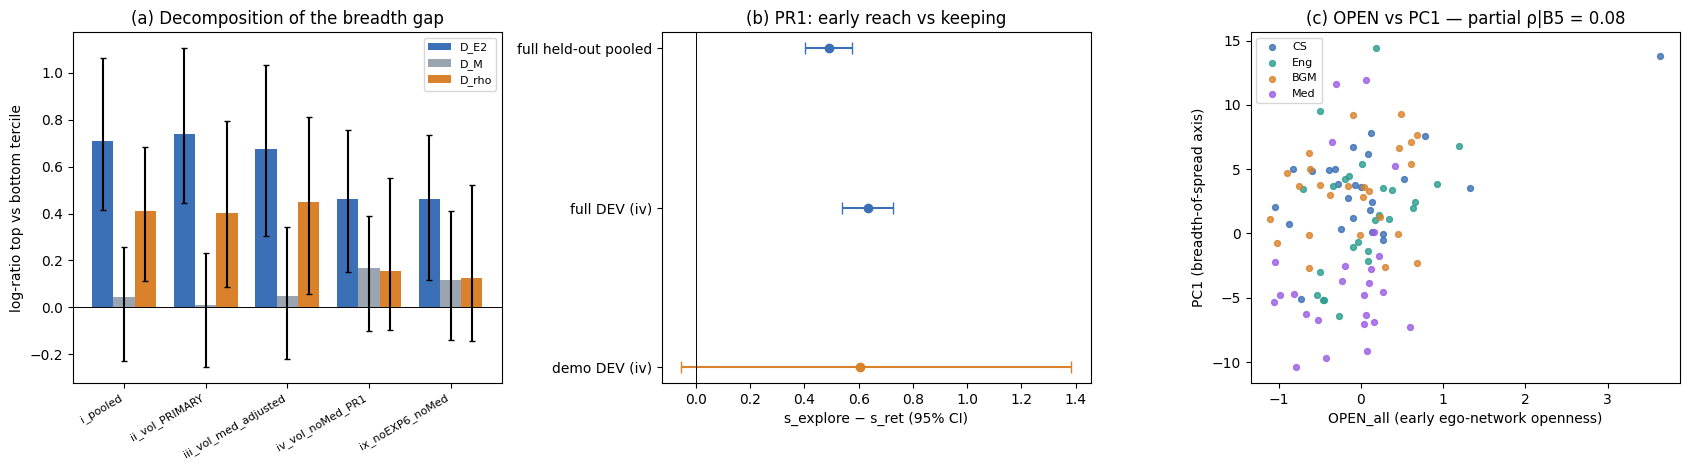

In [14]:
H = data["metadata"]["headline_full_run"]
rows = []
for name, r in res["variants"].items():
    p = r["point"]
    rows.append({"variant": name, "n_top": p["n_top"], "n_bot": p["n_bot"], "D_E2": p["D_E2"], "D_M": p["D_M"],
                 "D_rho": p["D_rho"], "s_E2": p["s_E2"], "s_M": p["s_M"], "s_rho": p["s_rho"],
                 "s_explore-s_ret": p["diff_explore_ret"],
                 "CI": np.round(r["ci"]["diff_explore_ret"], 3).tolist()})
tab = pd.DataFrame(rows).set_index("variant")
pd.set_option("display.width", 200)
print("=== Demo (100 DEV concepts) decomposition of the top-vs-bottom O2r_resid tercile gap ===")
print(tab.round(3).to_string())
print("\n=== Shares: demo vs full run (DEV, 4,771 concepts) ===")
cmp = pd.DataFrame({
    "demo primary (ii)": [res["variants"]["ii_vol_PRIMARY"]["point"][k] for k in ("s_E2", "s_M", "s_rho")],
    "full primary (ii)": [H["shares_DEV_primary"][k] for k in ("s_E2", "s_M", "s_rho")],
    "demo PR1 (iv)": [res["variants"]["iv_vol_noMed_PR1"]["point"][k] for k in ("s_E2", "s_M", "s_rho")],
    "full PR1 (iv)": [H["shares_DEV_PR1_variant"][k] for k in ("s_E2", "s_M", "s_rho")]},
    index=["s_E2 (early contact)", "s_M (frontier advance)", "s_rho (retention)"])
print(cmp.round(3).to_string())
print("\n=== Pre-registered verdicts ===")
ver = pd.DataFrame({"demo": {k: res["verdicts"][k]["verdict"] for k in ("PR1", "PR1b", "PR2")},
                    "full DEV": H["PR_verdicts_DEV"], "full held-out pooled": H["PR_verdicts_heldout_pooled4"],
                    "full cohort": H["PR_verdicts_cohort"]})
print(ver.to_string())
er = res["early_ratio_PR2"]
print(f"\nPR2 demo: RR_early bottom-top {er['diff_bottom_minus_top']:.3f} {np.round(er['ci'], 3).tolist()}; "
      f"psp|B5 {er['psp_given_B5']['rho']:.3f} {np.round(er['psp_given_B5']['ci'], 3).tolist()} "
      f"(full DEV: {H['PR2_DEV']['diff']:.3f}, psp {H['PR2_DEV']['psp']:.3f})")
dg = res["das_gupta_pooled"]; cc = res["concept_level_cov"]
print(f"Das Gupta shares (pooled): E2 {dg['share_E2']:.3f}  M {dg['share_M']:.3f}  rho {dg['share_rho']:.3f}")
print(f"Concept-level covariance shares: E2 {cc['share_E2']:.3f}  M {cc['share_M']:.3f}  rho {cc['share_rho']:.3f}"
      f"  (identity max err {cc['identity_max_abs_err']:.1e})")
pl = res["T9_placebo"]["iv_vol_noMed_PR1"]
print(f"T9 placebo (iv): D_total mean {pl['D_total']['mean']:.3f} band {np.round(pl['D_total']['q025_q975'], 3).tolist()}")

fig, axs = plt.subplots(1, 3, figsize=(17, 4.8))
# (a) D_k per variant
names = list(res["variants"])
xk = np.arange(len(names)); wdt = 0.26
for j, (k, c) in enumerate(zip(("D_E2", "D_M", "D_rho"), ("#3b6fb6", "#9aa5b1", "#d9822b"))):
    pts = [res["variants"][n]["point"][k] for n in names]
    ci = np.array([res["variants"][n]["ci"][k] for n in names])
    axs[0].bar(xk + (j - 1) * wdt, pts, wdt, color=c, label=k,
               yerr=[np.array(pts) - ci[:, 0], ci[:, 1] - np.array(pts)], capsize=2)
axs[0].axhline(0, color="k", lw=0.7)
axs[0].set_xticks(xk); axs[0].set_xticklabels(names, rotation=30, ha="right", fontsize=8)
axs[0].set_ylabel("log-ratio top vs bottom tercile"); axs[0].set_title("(a) Decomposition of the breadth gap")
axs[0].legend(fontsize=8)
# (b) PR1 statistic: demo vs full
lab = ["demo DEV (iv)", "full DEV (iv)", "full held-out pooled"]
pt = [res["verdicts"]["PR1"]["s_explore_minus_s_ret"], H["PR1_DEV"]["s_explore_minus_s_ret"],
      H["PR1_heldout_pooled4"]["s_explore_minus_s_ret"]]
ci = [res["verdicts"]["PR1"]["ci"], H["PR1_DEV"]["ci"], H["PR1_heldout_pooled4"]["ci"]]
for i, (p, c) in enumerate(zip(pt, ci)):
    axs[1].errorbar(p, i, xerr=[[p - c[0]], [c[1] - p]], fmt="o", color="#3b6fb6" if i else "#d9822b", capsize=4)
axs[1].axvline(0, color="k", lw=0.7); axs[1].set_yticks(range(3)); axs[1].set_yticklabels(lab)
axs[1].set_xlabel("s_explore − s_ret (95% CI)"); axs[1].set_title("(b) PR1: early reach vs keeping")
# (c) OPEN vs PC1
for g, c in zip(["CS", "Eng", "BGM", "Med"], ["#3b6fb6", "#2a9d8f", "#d9822b", "#9b5de5"]):
    s = T[T.group == g]
    axs[2].scatter(s.OPEN_all, s.PC1, s=18, alpha=0.8, color=c, label=g)
r = open_res["PC1"]["all"]["partial_given_B5_labelcov"]
axs[2].set_xlabel("OPEN_all (early ego-network openness)"); axs[2].set_ylabel("PC1 (breadth-of-spread axis)")
axs[2].set_title(f"(c) OPEN vs PC1 — partial ρ|B5 = {r['rho']:.2f}"); axs[2].legend(fontsize=8)
plt.tight_layout(); plt.show()